In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import gc

from scipy.signal import butter, filtfilt
from scipy.stats import kurtosis, skew

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### 2. FUNCIONES FILTRADO

In [12]:
def lowpass_filter(signal, cutoff=5000, fs=51200, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return filtfilt(b, a, signal)


def apply_highpass_filter(signal, cutoff=15000, fs=51200, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="high", analog=False)
    return filtfilt(b, a, signal)

### 3. FUNCIÓN EXTRACCIÓN DE CARACTERÍSTICAS

In [13]:
def extract_features_from_signal(signal, fs=51200):
    signal = np.asarray(signal, dtype=np.float32)

    features = {}

    # Dominio temporal
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    var_val = np.var(signal)
    max_val = np.max(signal)
    min_val = np.min(signal)
    ptp_val = np.ptp(signal)
    rms_val = np.sqrt(np.mean(signal**2))

    # Evitar divisiones por cero
    crest_factor_val = max_val / rms_val if rms_val != 0 else 0.0

    features["mean"] = mean_val
    features["std"] = std_val
    features["var"] = var_val
    features["max"] = max_val
    features["min"] = min_val
    features["ptp"] = ptp_val
    features["rms"] = rms_val
    features["kurtosis"] = kurtosis(signal)
    features["skewness"] = skew(signal)
    features["crest_factor"] = crest_factor_val

    # Dominio frecuencial
    fft_vals = np.abs(np.fft.rfft(signal))
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    features["fft_mean"] = np.mean(fft_vals)
    features["fft_std"] = np.std(fft_vals)
    features["fft_max"] = np.max(fft_vals)
    features["spectral_energy"] = np.sum(fft_vals**2)

    if len(fft_vals) >= 3:
        top_idx = np.argsort(fft_vals)[-3:][::-1]
        dom_freqs = fft_freqs[top_idx]
        features["dominant_freq_1"] = dom_freqs[0]
        features["dominant_freq_2"] = dom_freqs[1]
        features["dominant_freq_3"] = dom_freqs[2]
    else:
        features["dominant_freq_1"] = np.nan
        features["dominant_freq_2"] = np.nan
        features["dominant_freq_3"] = np.nan

    return features

### 4. CARGA DE LOS DATOS

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import gc
from tqdm import tqdm

def find_base_path(target_folder="bearing_fault_detection_processed_full"):
    """
    Busca la carpeta objetivo dentro de:
    Datos/Transformados/Industria
    """
    base_dir = Path.cwd().resolve()

    while not (base_dir / "Datos").exists() and base_dir.parent != base_dir:
        base_dir = base_dir.parent

    industria_dir = base_dir / "Datos" / "Transformados" / "Industria"

    if not industria_dir.exists():
        raise ValueError(f"No existe la carpeta esperada: {industria_dir}")

    matches = [p for p in industria_dir.rglob("*") if p.is_dir() and p.name == target_folder]

    if not matches:
        raise ValueError(
            f"No se encontró la carpeta '{target_folder}' dentro de {industria_dir}"
        )

    if len(matches) > 1:
        print("⚠️ Se encontraron varias carpetas. Usando la primera:")
        for m in matches:
            print("-", m)

    return matches[0].resolve()


base_path = find_base_path("bearing_fault_detection_processed_full")

FS = 51200
signal_cols = [
    "acc_under_axial",
    "acc_under_radiale",
    "acc_under_tangencial"
]

def infer_metadata_from_path(csv_path: Path, base_path: Path):
    rel_parts = csv_path.relative_to(base_path).parts[:-1]
    filename = csv_path.name

    mount_position = "none"
    label = "unknown"
    fault_level = "none"

    if len(rel_parts) == 1:
        label = rel_parts[0]
    elif len(rel_parts) == 2:
        label = rel_parts[0]
        fault_level = rel_parts[1]
    elif len(rel_parts) >= 3:
        mount_position = rel_parts[0]
        label = rel_parts[1]
        fault_level = rel_parts[2]

    return {
        "mount_position": mount_position,
        "label": label,
        "fault_level": fault_level,
        "source_file": str(Path(*rel_parts) / filename),
    }

def process_csv_file(csv_path, signal_cols, fs=FS):
    df = pd.read_csv(
        csv_path,
        usecols=signal_cols,
        dtype={col: np.float32 for col in signal_cols}
    )

    meta = infer_metadata_from_path(csv_path, base_path)

    row = {
        "mount_position": meta["mount_position"],
        "label": meta["label"],
        "fault_level": meta["fault_level"],
        "source_file": meta["source_file"],
    }

    for col in signal_cols:
        signal = df[col].to_numpy(dtype=np.float32)

        sig_lp = lowpass_filter(signal, cutoff=5000, fs=fs, order=4)
        sig_hp = apply_highpass_filter(signal, cutoff=15000, fs=fs, order=4)

        feats_lp = extract_features_from_signal(sig_lp, fs=fs)
        feats_hp = extract_features_from_signal(sig_hp, fs=fs)

        for k, v in feats_lp.items():
            row[f"{col}_lp_{k}"] = v

        for k, v in feats_hp.items():
            row[f"{col}_hp_{k}"] = v

        del signal, sig_lp, sig_hp

    del df
    gc.collect()
    return row

csv_files = list(base_path.rglob("*.csv"))

if not csv_files:
    raise ValueError(f"No se encontraron CSV dentro de: {base_path}")

features_list = []
for csv_path in tqdm(csv_files, desc="Extrayendo features archivo a archivo"):
    try:
        row = process_csv_file(csv_path, signal_cols, fs=FS)
        features_list.append(row)
    except Exception as e:
        print(f"Error en {csv_path}: {e}")

df_features_completo = pd.DataFrame(features_list)

ruta_salida = base_path.parent / "df_features_completo.csv"
df_features_completo.to_csv(ruta_salida, index=False)

print(" Carpeta encontrada:", base_path)
print("Archivo guardado en:", ruta_salida.resolve())
print("Shape:", df_features_completo.shape)

Extrayendo features archivo a archivo: 100%|██████████| 1951/1951 [11:14<00:00,  2.89it/s]


 Carpeta encontrada: C:\Bdata3\Verde_Oscuro_RETO11\Datos\Transformados\Industria\bearing_fault_detection_processed_full
Archivo guardado en: C:\Bdata3\Verde_Oscuro_RETO11\Datos\Transformados\Industria\df_features_completo.csv
Shape: (1951, 106)


### 4. SEPARAR FEATURES

In [29]:
df = pd.read_csv("./Datos/Transformados/Industria/df_features_completo.csv")

def detallar_etiqueta(row):
    label_original = str(row['label']).replace('-misalignment', '_misalignment')
    archivo = str(row['source_file']).lower()
    
    if label_original in ['ball_fault', 'cage_fault', 'outer_race']:
        if 'overhang' in archivo:
            return f"{label_original}_overhang"
        elif 'underhang' in archivo:
            return f"{label_original}_underhang"
            
    return label_original

df["detailed_label"] = df.apply(detallar_etiqueta, axis=1)
df

C:\Users\marke\AppData\Local\Temp\ipykernel_10380\329364354.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["detailed_label"] = df.apply(detallar_etiqueta, axis=1)


,mount_position,label,fault_level,source_file,acc_under_axial_lp_mean,acc_under_axial_lp_std,acc_under_axial_lp_var,acc_under_axial_lp_max,acc_under_axial_lp_min,acc_under_axial_lp_ptp,...,acc_under_tangencial_hp_skewness,acc_under_tangencial_hp_crest_factor,acc_under_tangencial_hp_fft_mean,acc_under_tangencial_hp_fft_std,acc_under_tangencial_hp_fft_max,acc_under_tangencial_hp_spectral_energy,acc_under_tangencial_hp_dominant_freq_1,acc_under_tangencial_hp_dominant_freq_2,acc_under_tangencial_hp_dominant_freq_3,detailed_label
0,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv,0.010543,0.545792,0.297889,1.483988,-1.988445,3.472433,...,-8.782607e-07,3.731492,2.088085,17.699127,1995.3593,39702716.0,22657.4336,22658.0480,22657.6384,horizontal_misalignment
1,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\13.5168.csv,0.040611,0.394051,0.155276,1.480436,-1.438261,2.918697,...,-1.642773e-06,2.674437,1.466058,16.411620,2870.6301,33936590.0,22646.3744,22645.9648,22646.5792,horizontal_misalignment
2,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\14.5408.csv,0.030735,0.382298,0.146152,1.285527,-1.487701,2.773227,...,-1.796093e-06,2.765885,1.489999,16.521166,3132.2603,34396400.0,22639.0016,22638.5920,22638.7968,horizontal_misalignment
3,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\15.36.csv,0.002370,0.318276,0.101300,1.036164,-1.327055,2.363218,...,2.762167e-05,2.939593,1.579939,16.407421,2707.7440,33962732.0,22633.4720,22633.0624,22633.2672,horizontal_misalignment
4,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\16.384.csv,0.004262,0.306836,0.094148,1.139856,-1.201884,2.341740,...,-2.697665e-05,2.668759,1.505402,16.333925,3291.4530,33633188.0,22610.5344,22610.3296,22610.7392,horizontal_misalignment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\57.9584.csv,0.008455,0.654038,0.427766,3.332246,-2.748418,6.080664,...,-6.188177e-03,11.186454,8.928163,13.568094,1634.9755,32975920.0,22555.0336,22794.8544,22554.8288,vertical_misalignment
1947,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\58.5728.csv,0.009506,0.620100,0.384524,2.938191,-2.060497,4.998688,...,4.766521e-04,10.402769,9.050273,13.779022,1683.0398,33971384.0,22554.4192,22794.4448,22554.6240,vertical_misalignment
1948,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\59.8016.csv,0.010230,0.617138,0.380860,2.705240,-2.099783,4.805023,...,3.470796e-03,10.113281,9.249165,13.989114,1539.7457,35155576.0,22554.0096,22554.2144,22794.0352,vertical_misalignment
1949,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\61.0304.csv,0.010549,0.621857,0.386706,2.692363,-2.556254,5.248617,...,-1.554637e-03,10.686070,9.506364,14.404739,1751.0753,37233730.0,22553.8048,22553.6000,22433.7920,vertical_misalignment


In [30]:
# Variable objetivo
y = df["detailed_label"]

# Columnas a eliminar
cols_to_drop = [
    "label",
    "fault_level",
    "mount_position",
    "source_file",
    "detailed_label"
]

# Crear X
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (1951, 102)
Shape de y: (1951,)


In [31]:
# Marcadores de variables frecuenciales
freq_markers = ["fft_", "spectral_", "dominant_freq_"]

# Variables temporales
time_features = [
    col for col in X.columns
    if not any(marker in col for marker in freq_markers)
]

# Variables frecuenciales
freq_features = [
    col for col in X.columns
    if any(marker in col for marker in freq_markers)
]

# Matrices de entrada
X_time = X[time_features]
X_freq = X[freq_features]
X_time_freq = X.copy()

print(f"Columnas del modelo temporal: {X_time.shape[1]}")
print(f"Columnas del modelo frecuencial: {X_freq.shape[1]}")
print(f"Columnas del modelo combinado: {X_time_freq.shape[1]}")

Columnas del modelo temporal: 60
Columnas del modelo frecuencial: 42
Columnas del modelo combinado: 102


20 de tiempo (10 LP + 10 HP)

14 de frecuencia (7 LP + 7 HP)

In [32]:
X_time

,acc_under_axial_lp_mean,acc_under_axial_lp_std,acc_under_axial_lp_var,acc_under_axial_lp_max,acc_under_axial_lp_min,acc_under_axial_lp_ptp,acc_under_axial_lp_rms,acc_under_axial_lp_kurtosis,acc_under_axial_lp_skewness,acc_under_axial_lp_crest_factor,...,acc_under_tangencial_hp_mean,acc_under_tangencial_hp_std,acc_under_tangencial_hp_var,acc_under_tangencial_hp_max,acc_under_tangencial_hp_min,acc_under_tangencial_hp_ptp,acc_under_tangencial_hp_rms,acc_under_tangencial_hp_kurtosis,acc_under_tangencial_hp_skewness,acc_under_tangencial_hp_crest_factor
0,0.010543,0.545792,0.297889,1.483988,-1.988445,3.472433,0.545894,-0.105065,-0.039365,2.718454,...,-7.146352e-08,0.035644,0.001270,0.133005,-0.129843,0.262848,0.035644,-0.251382,-8.782607e-07,3.731492
1,0.040611,0.394051,0.155276,1.480436,-1.438261,2.918697,0.396138,0.005468,0.185436,3.737168,...,-2.682448e-08,0.032954,0.001086,0.088134,-0.087760,0.175893,0.032954,-0.982092,-1.642773e-06,2.674437
2,0.030735,0.382298,0.146152,1.285527,-1.487701,2.773227,0.383531,0.044832,0.062539,3.351817,...,-5.424254e-08,0.033177,0.001101,0.091763,-0.093155,0.184918,0.033177,-0.976571,-1.796093e-06,2.765885
3,0.002370,0.318276,0.101300,1.036164,-1.327055,2.363218,0.318285,0.260607,0.003921,3.255457,...,-1.305346e-08,0.032967,0.001087,0.096909,-0.089916,0.186825,0.032967,-0.983902,2.762167e-05,2.939593
4,0.004262,0.306836,0.094148,1.139856,-1.201884,2.341740,0.306866,0.298742,0.155533,3.714510,...,2.940428e-08,0.032806,0.001076,0.087552,-0.088585,0.176137,0.032806,-1.009310,-2.697665e-05,2.668759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946,0.008455,0.654038,0.427766,3.332246,-2.748418,6.080664,0.654093,0.394567,0.167023,5.094452,...,2.480765e-08,0.032484,0.001055,0.363384,-0.396632,0.760015,0.032484,3.108363,-6.188177e-03,11.186454
1947,0.009506,0.620100,0.384524,2.938191,-2.060497,4.998688,0.620173,-0.059602,0.174650,4.737698,...,-7.801545e-08,0.032971,0.001087,0.342989,-0.402855,0.745843,0.032971,3.312289,4.766521e-04,10.402769
1948,0.010230,0.617138,0.380860,2.705240,-2.099783,4.805023,0.617223,-0.008586,0.248260,4.382921,...,8.964769e-08,0.033541,0.001125,0.339206,-0.342896,0.682103,0.033541,3.068365,3.470796e-03,10.113281
1949,0.010549,0.621857,0.386706,2.692363,-2.556254,5.248617,0.621946,-0.033704,0.179319,4.328931,...,-2.496172e-08,0.034518,0.001191,0.368858,-0.422083,0.790941,0.034518,2.962931,-1.554637e-03,10.686070


### 5. TRAIN / TEST SPLIT

In [33]:
from sklearn.model_selection import train_test_split

# Separamos los datos. 'stratify=y' es vital aquí para asegurar que en el examen 
# caiga al menos un motor de cada tipo de avería y no se quede ninguna clase fuera.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  
)

print(f"Motores para que el modelo estudie (Train): {X_train.shape[0]}")
print(f"Motores ocultos para el examen final (Test): {X_test.shape[0]}")

Motores para que el modelo estudie (Train): 1560
Motores ocultos para el examen final (Test): 391


### 6. MODELAJE

### 6.1. Random Forest

--- RESULTADOS FINALES ---
Accuracy (Precisión Global): 0.9949
------------------------------
                         precision    recall  f1-score   support

    ball_fault_overhang       1.00      1.00      1.00        27
   ball_fault_underhang       1.00      1.00      1.00        37
    cage_fault_overhang       1.00      1.00      1.00        38
   cage_fault_underhang       1.00      0.97      0.99        38
horizontal_misalignment       0.97      1.00      0.99        39
              imbalance       1.00      1.00      1.00        67
                 normal       1.00      0.90      0.95        10
    outer_race_overhang       1.00      1.00      1.00        38
   outer_race_underhang       0.97      1.00      0.99        37
  vertical_misalignment       1.00      1.00      1.00        60

               accuracy                           0.99       391
              macro avg       0.99      0.99      0.99       391
           weighted avg       1.00      0.99      0.99     

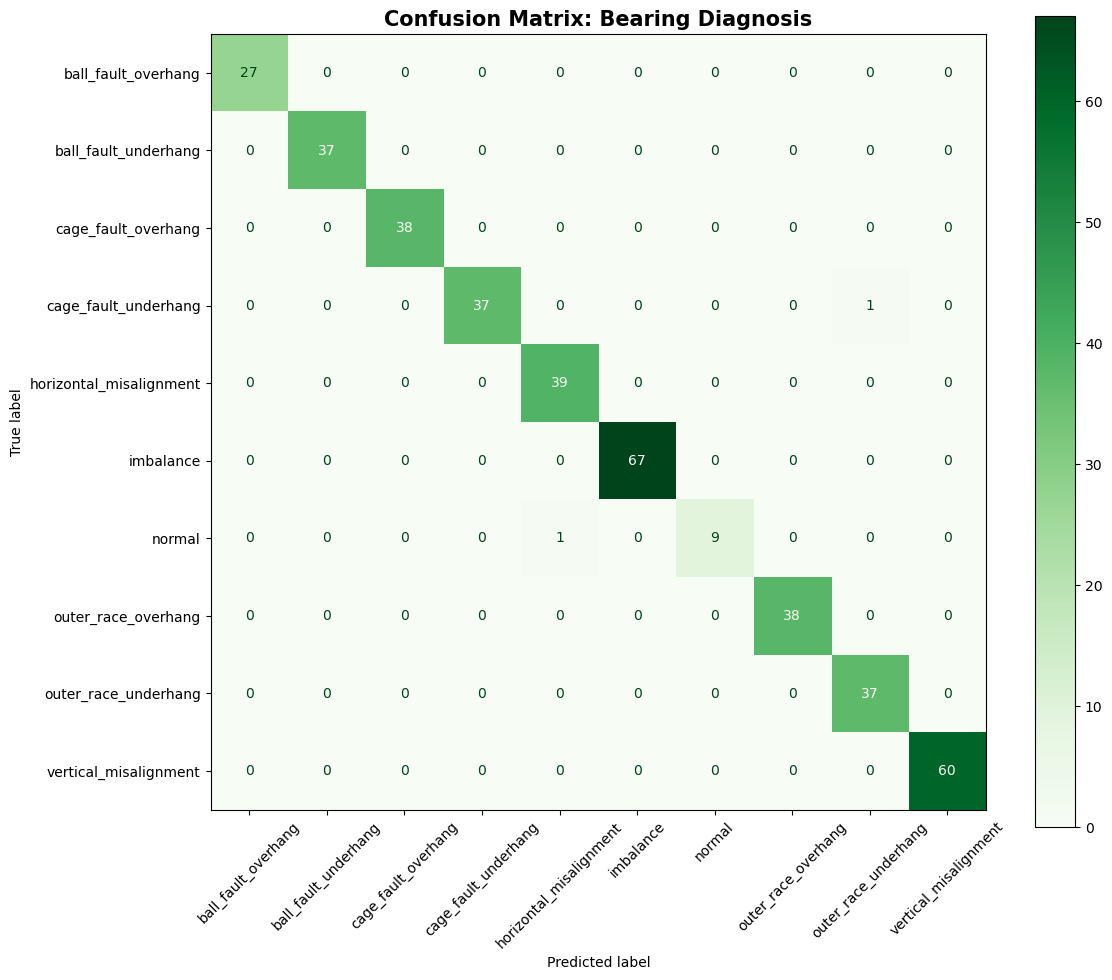

In [34]:
# 1. Creamos el "cerebro" del modelo
# Usamos n_jobs=-1 para que use todos los núcleos de tu procesador y termine antes
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1)

# 2. ENTRENAMIENTO (Aquí es donde el modelo aprende las 34 variables)
modelo_final.fit(X_train, y_train)

# 3. EL EXAMEN (Predicción sobre los datos que nunca ha visto)
y_pred = modelo_final.predict(X_test)

# 4. RESULTADOS
print(f"--- RESULTADOS FINALES ---")
print(f"Accuracy (Precisión Global): {accuracy_score(y_test, y_pred):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred))

# 5. MATRIZ DE CONFUSIÓN (Visualización clave para la presentación)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=modelo_final.classes_, 
    cmap='Greens', 
    xticks_rotation=45, 
    ax=ax
)
plt.title("Confusion Matrix: Bearing Diagnosis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    modelo_final,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(scores)
print("Mean accuracy:", scores.mean())

[0.8286445  0.96666667 0.91282051 0.92820513 0.91538462]
Mean accuracy: 0.9103442848711392


In [36]:
print("Scores por fold:", scores)
print("Accuracy media:", scores.mean())
print("Desviación estándar:", scores.std())

Scores por fold: [0.8286445  0.96666667 0.91282051 0.92820513 0.91538462]
Accuracy media: 0.9103442848711392
Desviación estándar: 0.04516107104864624


In [37]:
import pandas as pd

importances = modelo_final.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feat_imp = feat_imp.sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
58,acc_under_radiale_hp_kurtosis,0.052669
60,acc_under_radiale_hp_crest_factor,0.036387
52,acc_under_radiale_hp_std,0.035325
64,acc_under_radiale_hp_spectral_energy,0.031133
53,acc_under_radiale_hp_var,0.030684
10,acc_under_axial_lp_fft_mean,0.030175
54,acc_under_radiale_hp_max,0.029043
62,acc_under_radiale_hp_fft_std,0.028857
55,acc_under_radiale_hp_min,0.027544
56,acc_under_radiale_hp_ptp,0.027238


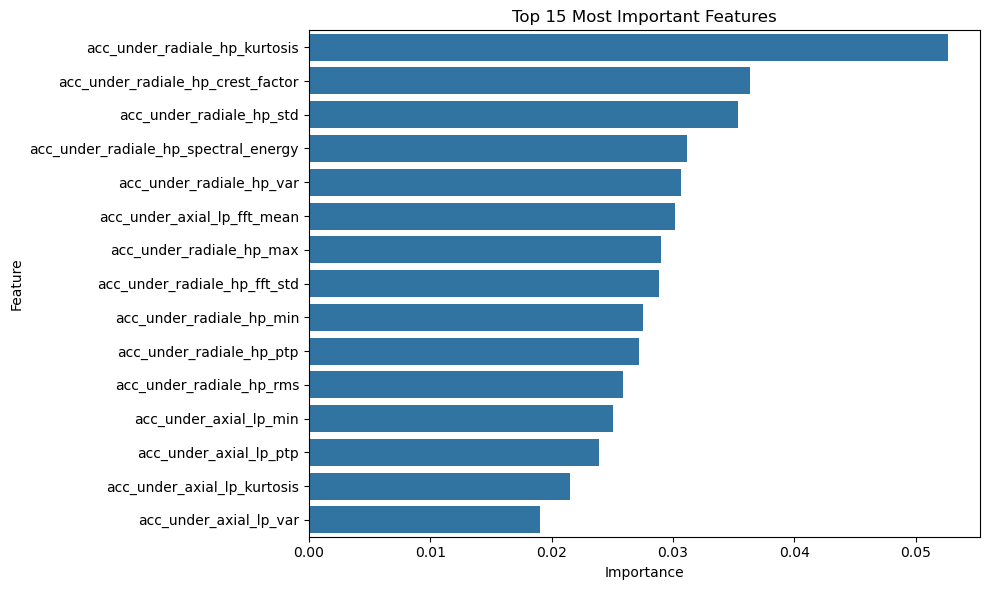

In [38]:

import matplotlib.pyplot as plt
import seaborn as sns

top_n = 15
top_features = feat_imp.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Solo tiempo - Random Forest

In [39]:
scores_time = cross_val_score(
    modelo_final,
    X_time,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy tiempo:", scores_time.mean())

Accuracy tiempo: 0.9072529346186634


### Solo frecuencia - Random Forest

In [40]:
scores_freq = cross_val_score(
    modelo_final,
    X_freq,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy frecuencia:", scores_freq.mean())

Accuracy frecuencia: 0.844726867335563


### Tiempo + frecuencia - Random Forest

In [41]:
scores_all = cross_val_score(
    modelo_final,
    X_time_freq,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy combinado:", scores_all.mean())

Accuracy combinado: 0.9103442848711392


In [42]:
lp_features = [col for col in X.columns if "_lp_" in col]
hp_features = [col for col in X.columns if "_hp_" in col]

X_lp = X[lp_features]
X_hp = X[hp_features]

In [43]:
scores_lp = cross_val_score(modelo_final, X_lp, y, cv=5)
scores_hp = cross_val_score(modelo_final, X_hp, y, cv=5)

print("LP:", scores_lp.mean())
print("HP:", scores_hp.mean())

LP: 0.7934513738605811
HP: 0.7934710472817889


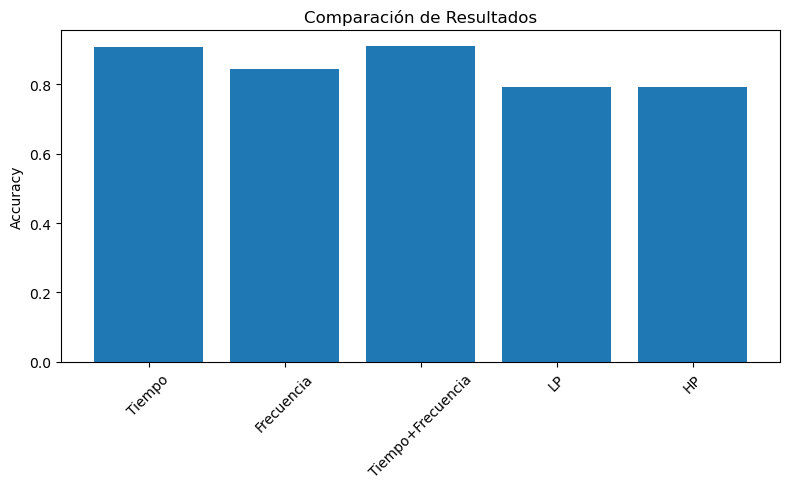

In [44]:
resultados = {
    "Tiempo": scores_time.mean(),
    "Frecuencia": scores_freq.mean(),
    "Tiempo+Frecuencia": scores_all.mean(),
    "LP": scores_lp.mean(),
    "HP": scores_hp.mean()
}

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(resultados.keys(), resultados.values())
plt.title("Comparación de Resultados")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Guardamos modelo

In [47]:
import joblib

joblib.dump(modelo_final, "./Datos/Transformados/Industria/modelo_random_forest_final.pkl")

['./Datos/Transformados/Industria/modelo_random_forest_final.pkl']

### 6.2. Gradient Boosting

In [48]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre="Modelo"):
    
    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicción
    y_pred = modelo.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    print(f"\n--- RESULTADOS {nombre} ---")
    print(f"Accuracy: {acc:.4f}")
    print("-" * 30)
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(12,10))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=modelo.classes_,
        cmap="Greens",
        xticks_rotation=45,
        ax=ax
    )

    plt.title(f"Matriz de Confusión - {nombre}")
    plt.tight_layout()
    plt.show()

    return acc

In [49]:
def plot_feature_importance(modelo, X, top_n=15, nombre="Modelo"):

    if hasattr(modelo, "feature_importances_"):

        importances = modelo.feature_importances_

        feat_imp = pd.DataFrame({
            "feature": X.columns,
            "importance": importances
        })

        feat_imp = feat_imp.sort_values(
            "importance",
            ascending=False
        ).head(top_n)

        plt.figure(figsize=(10,6))

        plt.barh(
            feat_imp["feature"],
            feat_imp["importance"]
        )

        plt.gca().invert_yaxis()

        plt.title(f"Top {top_n} Features - {nombre}")

        plt.tight_layout()
        plt.show()

    else:
        print(f"{nombre} no soporta feature_importances_")

In [50]:
from sklearn.model_selection import cross_val_score

def comparar_dominios(modelo, X_time, X_freq, X_all, y):

    scores_time = cross_val_score(
        modelo,
        X_time,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    scores_freq = cross_val_score(
        modelo,
        X_freq,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    scores_all = cross_val_score(
        modelo,
        X_all,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    print("\n--- Comparación dominios ---")

    print("Tiempo:", scores_time.mean())
    print("Frecuencia:", scores_freq.mean())
    print("Tiempo+Frecuencia:", scores_all.mean())

    return {
        "Tiempo": scores_time.mean(),
        "Frecuencia": scores_freq.mean(),
        "Tiempo+Frecuencia": scores_all.mean()
    }

In [51]:
resultados_modelos = {}


--- RESULTADOS Random Forest ---
Accuracy: 0.9949
------------------------------
                         precision    recall  f1-score   support

    ball_fault_overhang       1.00      1.00      1.00        27
   ball_fault_underhang       1.00      1.00      1.00        37
    cage_fault_overhang       1.00      1.00      1.00        38
   cage_fault_underhang       1.00      0.97      0.99        38
horizontal_misalignment       0.97      1.00      0.99        39
              imbalance       1.00      1.00      1.00        67
                 normal       1.00      0.90      0.95        10
    outer_race_overhang       1.00      1.00      1.00        38
   outer_race_underhang       0.97      1.00      0.99        37
  vertical_misalignment       1.00      1.00      1.00        60

               accuracy                           0.99       391
              macro avg       0.99      0.99      0.99       391
           weighted avg       1.00      0.99      0.99       391



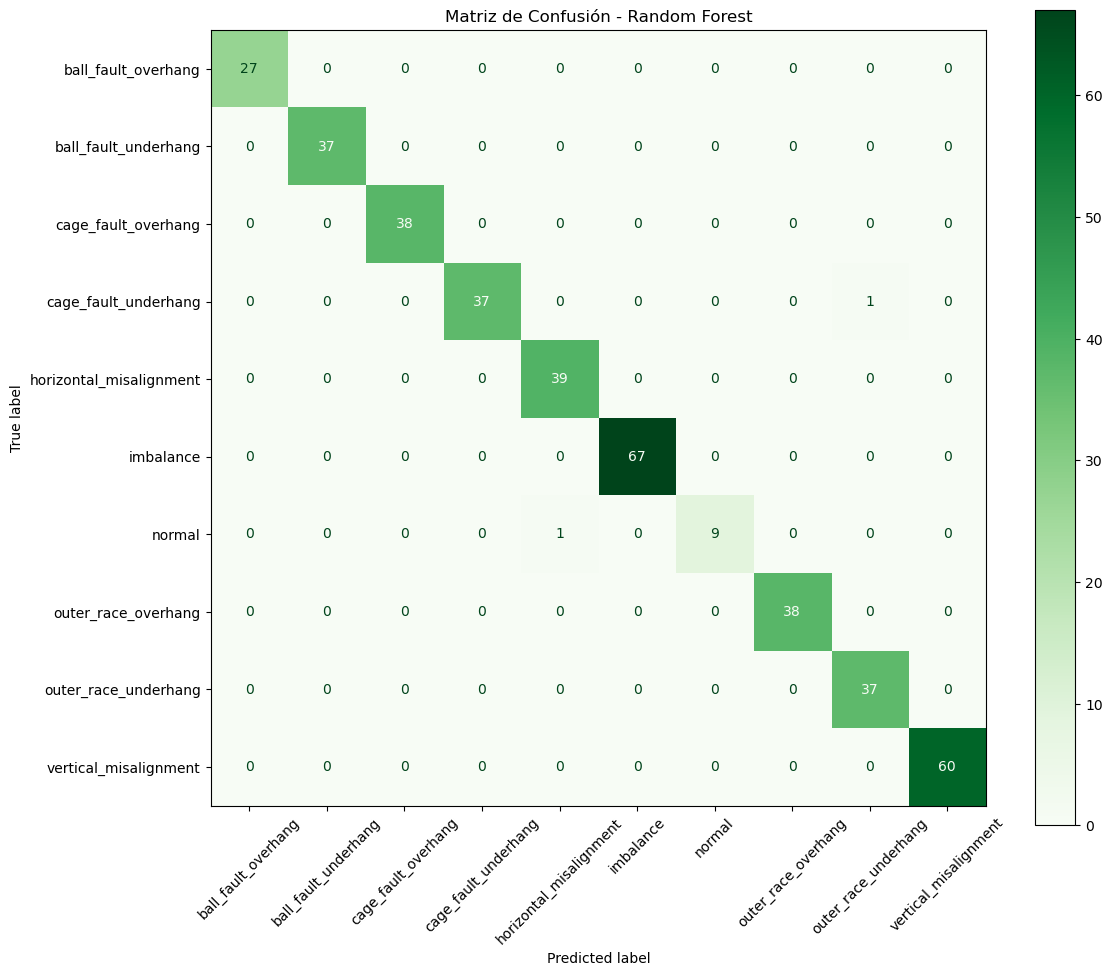

In [52]:
acc_rf = evaluar_modelo(
    modelo_final,
    X_train,
    X_test,
    y_train,
    y_test,
    nombre="Random Forest"
)

resultados_modelos["Random Forest"] = acc_rf


--- RESULTADOS Gradient Boosting ---
Accuracy: 0.9872
------------------------------
                         precision    recall  f1-score   support

    ball_fault_overhang       1.00      0.96      0.98        27
   ball_fault_underhang       1.00      1.00      1.00        37
    cage_fault_overhang       1.00      1.00      1.00        38
   cage_fault_underhang       0.95      0.97      0.96        38
horizontal_misalignment       0.97      0.97      0.97        39
              imbalance       1.00      0.99      0.99        67
                 normal       1.00      0.90      0.95        10
    outer_race_overhang       1.00      1.00      1.00        38
   outer_race_underhang       0.95      1.00      0.97        37
  vertical_misalignment       1.00      1.00      1.00        60

               accuracy                           0.99       391
              macro avg       0.99      0.98      0.98       391
           weighted avg       0.99      0.99      0.99       391



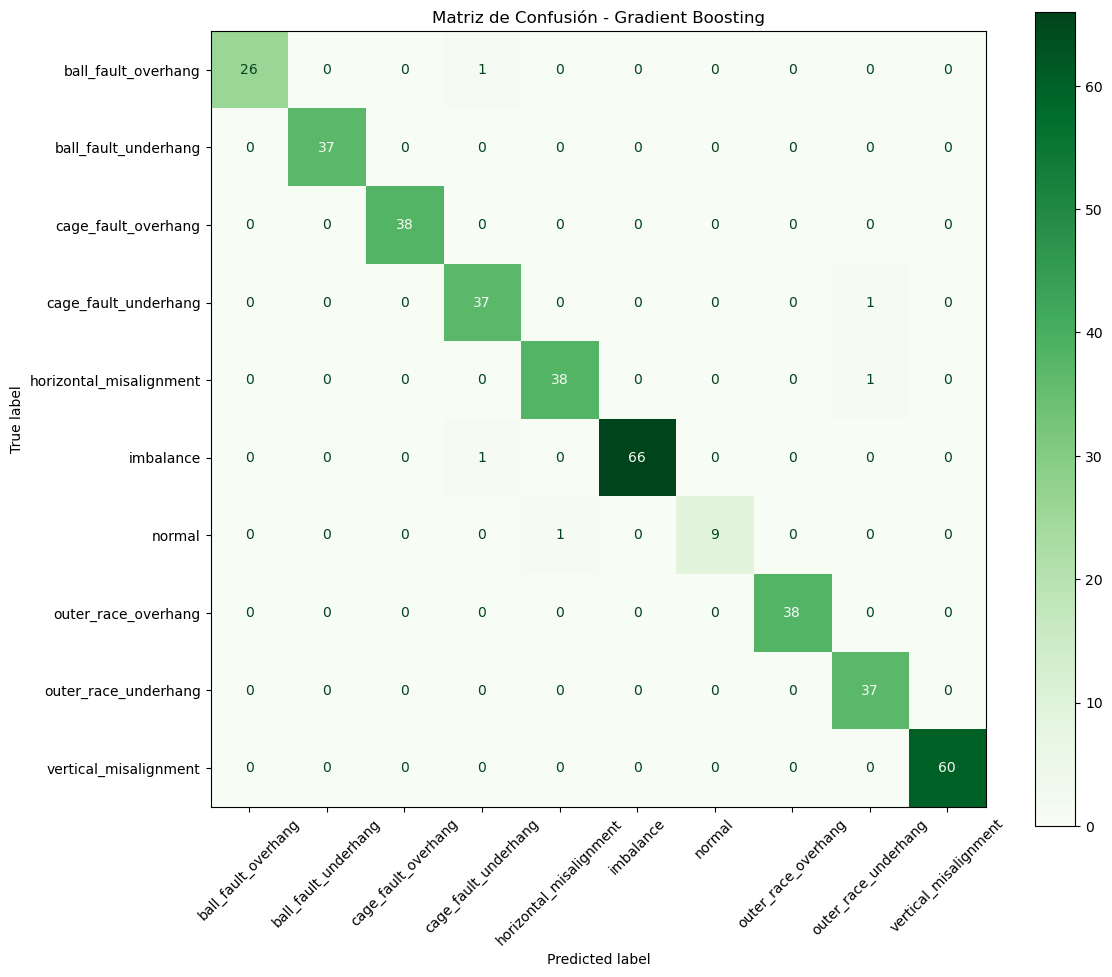

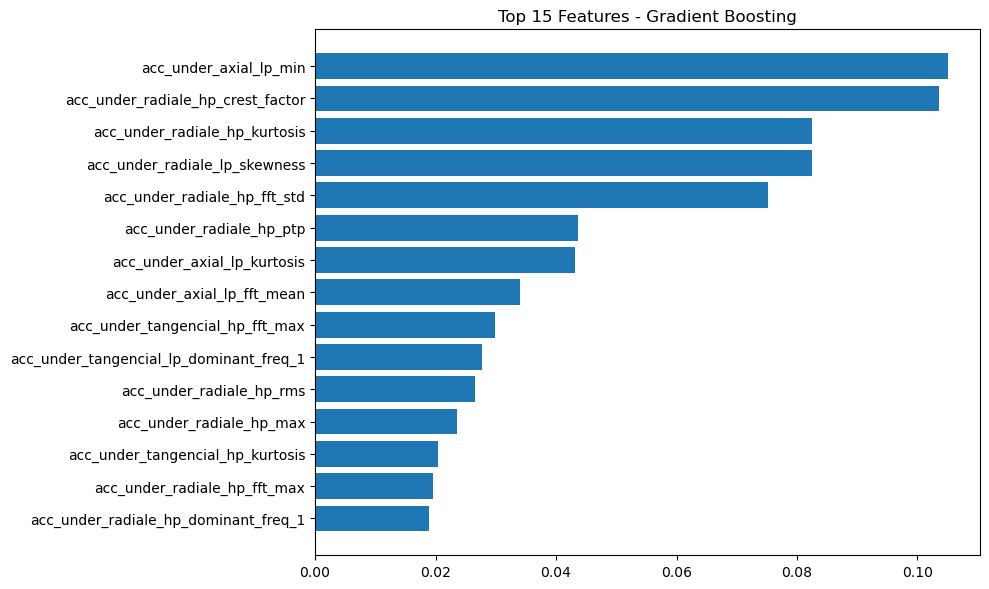

In [53]:
modelo_gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

acc_gb = evaluar_modelo(
    modelo_gb,
    X_train,
    X_test,
    y_train,
    y_test,
    nombre="Gradient Boosting"
)

resultados_modelos["Gradient Boosting"] = acc_gb

plot_feature_importance(
    modelo_gb,
    X,
    nombre="Gradient Boosting"
)

Accuracy XGBoost: 0.9898
                         precision    recall  f1-score   support

    ball_fault_overhang       1.00      1.00      1.00        27
   ball_fault_underhang       1.00      1.00      1.00        37
    cage_fault_overhang       1.00      1.00      1.00        38
   cage_fault_underhang       1.00      1.00      1.00        38
horizontal_misalignment       0.97      0.92      0.95        39
              imbalance       0.99      1.00      0.99        67
                 normal       1.00      0.90      0.95        10
    outer_race_overhang       1.00      1.00      1.00        38
   outer_race_underhang       0.95      1.00      0.97        37
  vertical_misalignment       1.00      1.00      1.00        60

               accuracy                           0.99       391
              macro avg       0.99      0.98      0.99       391
           weighted avg       0.99      0.99      0.99       391



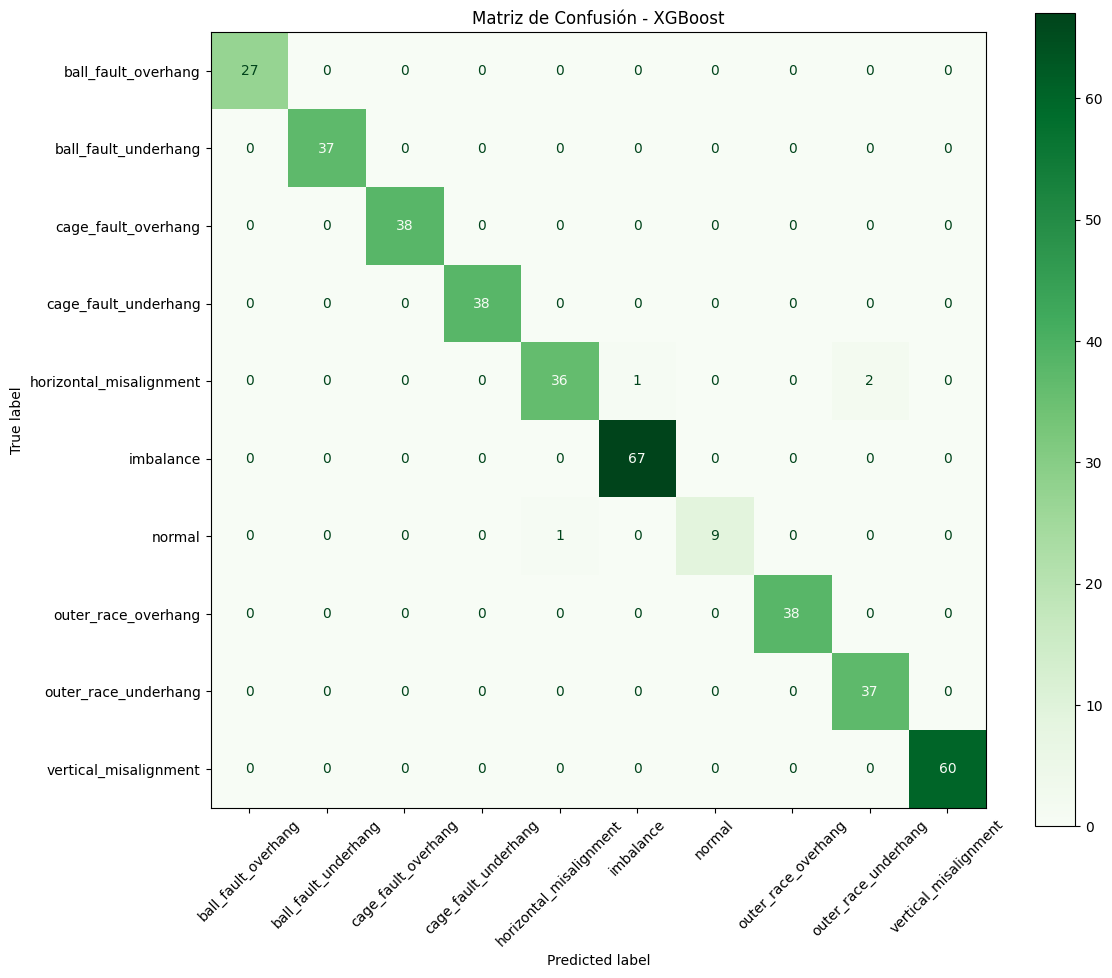

In [ ]:
from xgboost import XGBClassifier

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Nuevo split para XGBoost
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Modelo
modelo_xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss"
)

# Entrenamiento
modelo_xgb.fit(X_train_xgb, y_train_xgb)

# Predicción
y_pred_xgb = modelo_xgb.predict(X_test_xgb)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
print(f"Accuracy XGBoost: {acc_xgb:.4f}")

# Reporte con nombres originales
print(classification_report(
    y_test_xgb,
    y_pred_xgb,
    target_names=le.classes_
))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(12,10))
ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    y_pred_xgb,
    display_labels=le.classes_,
    cmap="Greens",
    xticks_rotation=45,
    ax=ax
)
plt.title("Matriz de Confusión - XGBoost")
plt.tight_layout()
plt.show()

# Guardar resultado
resultados_modelos["XGBoost"] = acc_xgb

plot_feature_importance(
    modelo_xgb,
    X,
    nombre="XGBoost"
)


In [76]:
from sklearn.model_selection import cross_val_score

# Cross-validation modelos
scores_rf = cross_val_score(
    modelo_final,
    X_time_freq,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

scores_gb = cross_val_score(
    modelo_gb,
    X_time_freq,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

scores_xgb = cross_val_score(
    modelo_xgb,
    X_time_freq,
    y_encoded,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


In [ ]:
# MODELOS (con std)
datos_modelos = [
    ("Modelo", "Random Forest",
     scores_rf.mean(), scores_rf.std()),

    ("Modelo", "Gradient Boosting",
     scores_gb.mean(), scores_gb.std()),

    ("Modelo", "XGBoost",
     scores_xgb.mean(), scores_xgb.std())
]

# DOMINIOS (sin std)
datos_dominios = [
    ("Dominio", "Solo tiempo",
     scores_time.mean(), None),

    ("Dominio", "Solo frecuencia",
     scores_freq.mean(), None),

    ("Dominio", "Tiempo + frecuencia",
     scores_all.mean(), None)
]

# FILTROS (sin std)
datos_filtros = [
    ("Filtro", "Low-pass (LP)",
     scores_lp.mean(), None),

    ("Filtro", "High-pass (HP)",
     scores_hp.mean(), None)
]

# UNIMOS TODO
datos_totales = (
    datos_modelos +
    datos_dominios +
    datos_filtros
)

# Creamos tabla completa
tabla_final = pd.DataFrame(
    datos_totales,
    columns=["Categoría", "Nombre", "Accuracy", "Std"]
)

# Redondear valores
tabla_final["Accuracy"] = tabla_final["Accuracy"].round(4)
tabla_final["Std"] = tabla_final["Std"].round(4)

# Ordenar por categoría
tabla_final = tabla_final.sort_values(
    by=["Categoría", "Accuracy"],
    ascending=[True, False]
)

# PRINT POR BLOQUES
for categoria in tabla_final["Categoría"].unique():

    print(f"\n--- {categoria.upper()} ---\n")

    subtabla = tabla_final[
        tabla_final["Categoría"] == categoria
    ]

    # Mostrar Std solo si existe
    if subtabla["Std"].notna().any():

        print(
            subtabla[
                ["Nombre", "Accuracy", "Std"]
            ].to_string(index=False)
        )

    else:

        print(
            subtabla[
                ["Nombre", "Accuracy"]
            ].to_string(index=False)
        )


--- DOMINIO ---

             Nombre  Accuracy
Tiempo + frecuencia    0.9073
        Solo tiempo    0.9057
    Solo frecuencia    0.8447

--- FILTRO ---

        Nombre  Accuracy
 Low-pass (LP)     0.795
High-pass (HP)     0.794

--- MODELO ---

           Nombre  Accuracy    Std
Gradient Boosting    0.9201 0.0513
    Random Forest    0.9073 0.0379
          XGBoost    0.9073 0.0502


In [73]:
for categoria in tabla_final["Categoría"].unique():
    
    print(f"\n--- {categoria.upper()} ---\n")
    
    print(
        tabla_final[
            tabla_final["Categoría"] == categoria
        ][["Nombre", "Accuracy"]]
        .to_string(index=False)
    )


--- MODELO ---

           Nombre  Accuracy
Gradient Boosting  0.920092
          XGBoost  0.907274
    Random Forest  0.907261


In [69]:
print(scores_rf.mean())
print(scores_gb.mean())
print(scores_xgb.mean())

0.9072608039871468
0.9200918092989705
0.9072739196012855
